In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
from scipy.optimize import curve_fit
import matplotlib.colors as mcolors

_dpi = 200


def colormap(num_colors, name = 'rainbow') :
    cmap = mpl.cm.get_cmap(name = name, lut = num_colors)
    return cmap(range(num_colors))

#(10,10), size = 25

rc('text', usetex=False)
rc('font', family='serif', size = 20)

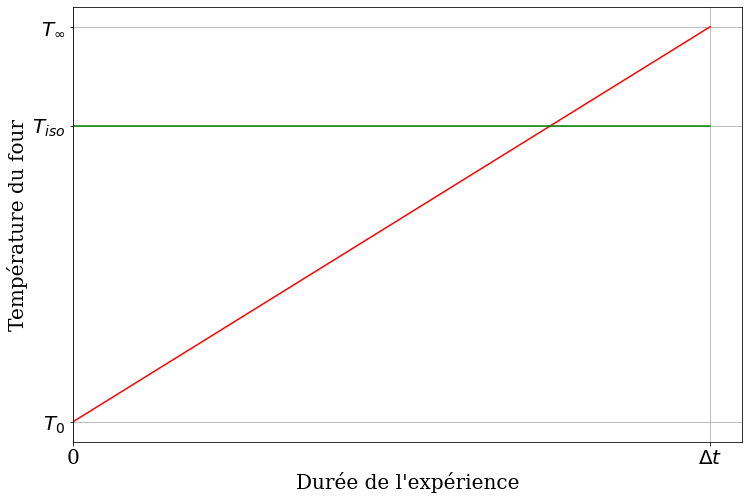

In [99]:
name = "Fig04a"

t = np.linspace(0, 100, num=101)

T0_iso = 100 
T0_ramp = 25
v = 1

TE = lambda t, T0=0, v=0 : T0 + v * t



fig = plt.figure(figsize = (12,8))
ax = fig.subplots()
ax.plot(t, TE(t, v=v, T0=T0_ramp), color = 'red')
ax.plot(t, TE(t, v=0, T0 = T0_iso), color = 'green')

#ax.set_ylim(min(T0, Tinfty),max(T0, Tinfty))
ax.set_xlim(0,None)

ax.set_xticks([0,t.max()])
ax.set_xticklabels([0, "$\Delta t$"])

ax.set_yticks([T0_ramp, T0_iso, T0_ramp + v*t.max()])
ax.set_yticklabels(["$T_0$", "$T_{iso}$", "$T_\\infty$"])

ax.set_xlabel("Durée de l'expérience")
ax.set_ylabel("Température du four")

ax.grid()

fig.savefig(name + ".pdf", dpi = _dpi)

In [222]:
name = "Fig04b"

T0 = 25
v = 1
tau_r = 0.5
tau_e = 1.8

tmin = 0
tmax = 10

T = lambda t, tau=0, T0=0, v=0 : TE(t, T0=T0, v=v) + tau * v * (np.exp(-t/tau)-1)

Tlim = lambda t, tau=0, T0=0, v=0 : TE(t, T0=T0, v=v) - tau * v

t = np.linspace(tmin, tmax, num = 101)
taxis = np.arange(tmin, tmax+1)

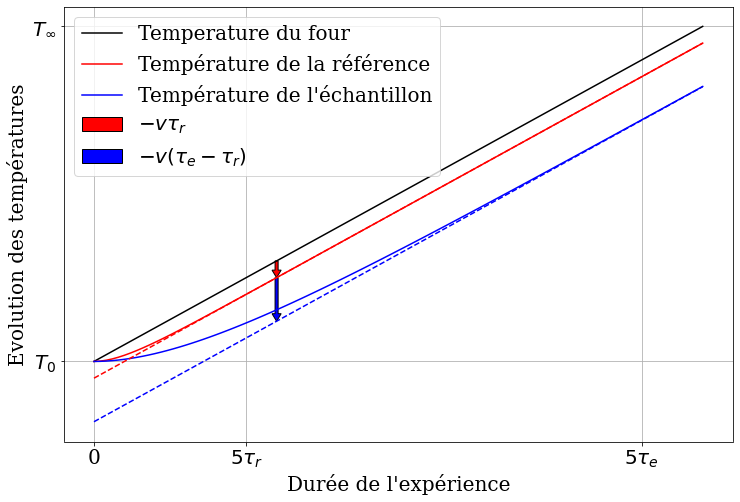

In [223]:
fig = plt.figure(figsize = (12,8))
ax = fig.subplots()
ax.plot(t, TE(t, T0 = T0, v = v), color = 'black', label = "Temperature du four")
ax.plot(t, T(t, tau = tau_r, T0 = T0, v = v), color = 'red', label = "Température de la référence")
ax.plot(t, T(t, tau = tau_e, T0 = T0, v = v), color = 'blue', label = "Température de l'échantillon")

ax.plot(t, Tlim(t, tau = tau_r, T0 = T0, v = v), color = 'red', ls = 'dashed')
ax.plot(t, Tlim(t, tau = tau_e, T0 = T0, v = v), color = 'blue', ls = 'dashed')
#ax.plot(t, Ti(t), color = 'red')

#ax.set_ylim(min(T0, Tinfty),max(T0, Tinfty))
#ax.set_xlim(0,5)



ax.arrow(6*tau_r, TE(6*tau_r, T0 = T0, v = v), 
         0, Tlim(6*tau_r, tau = tau_r, T0 = T0, v = v)-
         TE(6*tau_r, T0 = T0, v = v), width=0.05,
        length_includes_head=True, edgecolor = "black",
        facecolor = 'red', label = "$-v\\tau_r$")

ax.arrow(6*tau_r, Tlim(6*tau_r, tau = tau_r, T0 = T0, v = v), 
         0, Tlim(6*tau_r, tau = tau_e, T0 = T0, v = v)-
         Tlim(6*tau_r, tau = tau_r, T0 = T0, v = v), width=0.05,
        length_includes_head=True, edgecolor = "black",
        facecolor = 'blue', label = "$-v(\\tau_e-\\tau_r)$")

ax.set_xticks([0, 5*tau_r, 5 * tau_e])
ax.set_xticklabels(["0", "$5 \\tau_r$", "$5 \\tau_e$"])

ax.set_yticks([T0, TE(tmax, T0 = T0, v = v)])
ax.set_yticklabels(["$T_0$","$T_\\infty$"])

ax.set_xlabel("Durée de l'expérience")
ax.set_ylabel("Evolution des températures")

ax.legend()
ax.grid()

fig.savefig(name + ".pdf", dpi = _dpi)

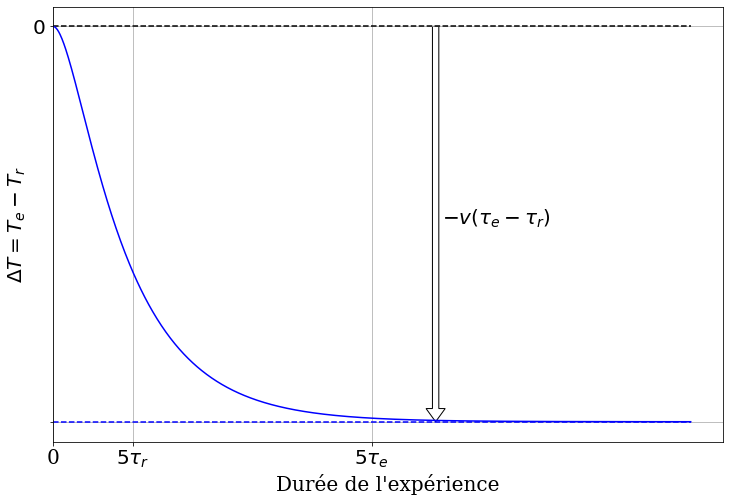

In [219]:
name = "Fig04d"

DT = Tlim(6*tau_e, tau = tau_e, T0 = T0, v = v) - Tlim(6*tau_e, tau = tau_r, T0 = T0, v = v)

fig = plt.figure(figsize = (12,8))
ax = fig.subplots()
ax.plot(t, 0 * TE(t, T0 = T0, v = v), color = 'black', ls = 'dashed')
ax.plot(t, T(t, tau = tau_e, T0 = T0, v = v) - T(t, tau = tau_r, T0 = T0, v = v), color = 'blue')
ax.plot(t, Tlim(t, tau = tau_e, T0 = T0, v = v) - Tlim(t, tau = tau_r, T0 = T0, v = v), color = 'blue', ls = "dashed")

ax.arrow(6*tau_e, 0, 
         0, DT, width=0.2,
        length_includes_head=True, edgecolor = "black", head_length = 0.05,
        facecolor = 'white', label = "$-v(\\tau_e-\\tau_r)$")
ax.annotate("$-v (\\tau_e-\\tau_r)$", (6*tau_e, DT/2), 
            xytext = (6.1*tau_e, DT/2))

ax.set_xticks([0, 5*tau_r, 5 * tau_e])
ax.set_xticklabels(["0", "$5 \\tau_r$", "$5 \\tau_e$"])

ax.set_yticks([0,  Tlim(6*tau_e, tau = tau_e, T0 = T0, v = v) - Tlim(6*tau_e, tau = tau_r, T0 = T0, v = v)])
ax.set_yticklabels(["$0$",""])

ax.set_xlabel("Durée de l'expérience")
ax.set_ylabel("$\Delta T = T_e - T_r$")

ax.set_xlim(0,None)

#ax.legend()
ax.grid()

fig.savefig(name + ".pdf", dpi = _dpi)

In [135]:
name = "Fig04c"

T0 = 25
v = 1
tau_r = 0.5
tau_e = 2

tmin = 0
tmax = 10*tau_e

T = lambda t, tau=0, T0=0, v=0 : TE(t, T0=T0, v=v) + tau * v * (np.exp(-t/tau)-1)
T2 = lambda t, tau=0, T0=0, v=0 : TE(t, T0=T0, v=v) - tau * v * (np.exp(-t/tau)-1)

Tlim = lambda t, tau=0, T0=0, v=0 : TE(t, T0=T0, v=v) - tau * v

T_trans = T(tau_e*6, tau = tau_e, T0 = T0, v = v)

t = np.linspace(tmin, tmax, num = 1001)
taxis = np.arange(tmin, tmax+1)

mask = [t > 6*tau_e, t < 7*tau_e]

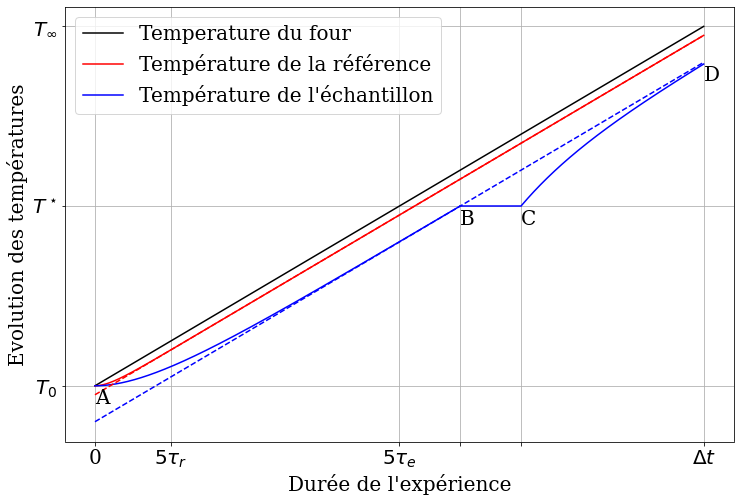

In [216]:
fig = plt.figure(figsize = (12,8))
ax = fig.subplots()
ax.plot(t, TE(t, T0 = T0, v = v), color = 'black', label = "Temperature du four")
ax.plot(t, T(t, tau = tau_r, T0 = T0, v = v), color = 'red', label = "Température de la référence")
ax.plot(np.ma.masked_greater_equal(t, 6*tau_e), T(t, tau = tau_e, T0 = T0, v = v), 
        color = 'blue', label = "Température de l'échantillon")
ax.plot([6*tau_e, 7*tau_e], [T_trans, T_trans], color = "blue")
ax.plot(np.ma.masked_less_equal(t, 7*tau_e), T2(t-7*tau_e, tau = tau_e, T0 = T_trans, v = v), 
        color = 'blue')


#ax.plot(t, T(t, tau = tau_e, T0 = T_trans, v = v), color = 'blue', label = "Température de l'échantillon")


ax.plot(t, Tlim(t, tau = tau_r, T0 = T0, v = v), color = 'red', ls = 'dashed')
ax.plot(t, Tlim(t, tau = tau_e, T0 = T0, v = v), color = 'blue', ls = 'dashed')

ax.annotate("A", (0, T0), xytext = (0, T0-1))
ax.annotate("B", (6*tau_e, T_trans), xytext = (6*tau_e, T_trans-1))
ax.annotate("C", (6*tau_e, T_trans), xytext = (7*tau_e, T_trans-1))
ax.annotate("D", (tmax, T(tmax, tau = tau_e, T0 = T0, v = v)), 
            xytext = (tmax, T(tmax, tau = tau_e, T0 = T0, v = v)-1))

ax.set_yticks([T0, T_trans, TE(tmax, T0 = T0, v = v)])
ax.set_yticklabels(["$T_0$", "$T^\star$", "$T_\infty$"])

#ax.plot(t, Ti(t), color = 'red')

#ax.set_ylim(min(T0, Tinfty),max(T0, Tinfty))
#ax.set_xlim(0,5)


"""
ax.arrow(6*tau_r, TE(6*tau_r, T0 = T0, v = v), 
         0, Tlim(6*tau_r, tau = tau_r, T0 = T0, v = v)-
         TE(6*tau_r, T0 = T0, v = v), width=0.05,
        length_includes_head=True, edgecolor = "black",
        facecolor = 'red', label = "$-v\\tau_r$")

ax.arrow(6*tau_r, Tlim(6*tau_r, tau = tau_r, T0 = T0, v = v), 
         0, Tlim(6*tau_r, tau = tau_e, T0 = T0, v = v)-
         Tlim(6*tau_r, tau = tau_r, T0 = T0, v = v), width=0.05,
        length_includes_head=True, edgecolor = "black",
        facecolor = 'blue', label = "$-v(\\tau_e-\\tau_r)$")"""

ax.set_xticks([0, 5*tau_r, 5 * tau_e, 6 * tau_e, 7 * tau_e, tmax])
ax.set_xticklabels(["0", "$5 \\tau_r$", "$5 \\tau_e$", "", "", "$\Delta t$"])

ax.set_xlabel("Durée de l'expérience")
ax.set_ylabel("Evolution des températures")

ax.legend()
ax.grid()

fig.savefig(name + ".pdf", dpi = _dpi)

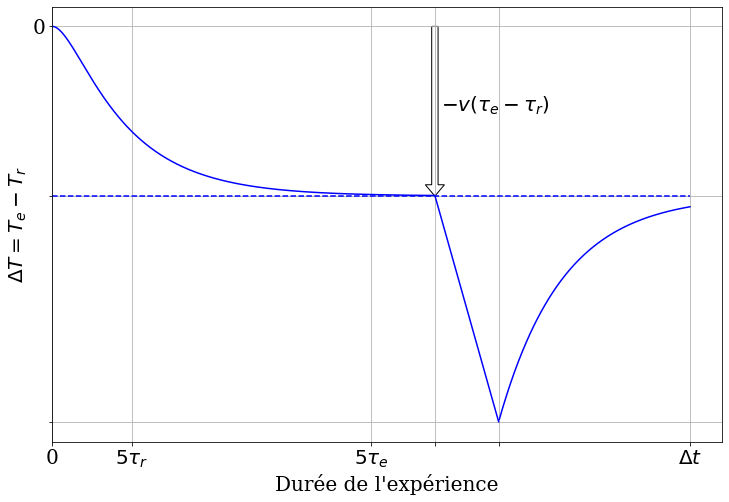

In [221]:
name = "Fig04e"

fig = plt.figure(figsize = (12,8))
ax = fig.subplots()
#ax.plot(t, TE(t, T0 = T0, v = v), color = 'black', label = "Temperature du four")

#ax.plot(t, T(t, tau = tau_r, T0 = T0, v = v), color = 'red', label = "Température de la référence")
ax.plot(np.ma.masked_greater_equal(t, 6*tau_e), T(t, tau = tau_e, T0 = T0, v = v) - T(t, tau = tau_r, T0 = T0, v = v), 
        color = 'blue', label = "Température de l'échantillon")
ax.plot(np.ma.masked_outside(t, 6*tau_e, 7*tau_e), T_trans - T(t, tau = tau_r, T0 = T0, v = v), color = "blue")
ax.plot(np.ma.masked_less_equal(t, 7*tau_e), T2(t-7*tau_e, tau = tau_e, T0 = T_trans, v = v) - T(t, tau = tau_r, T0 = T0, v = v), 
        color = 'blue')

ax.plot(t, Tlim(t, tau = tau_e, T0 = T0, v = v) -  Tlim(t, tau = tau_r, T0 = T0, v = v), color = 'blue', ls = 'dashed')

ax.arrow(6*tau_e, 0, 
         0, DT, width=0.2,
        length_includes_head=True, edgecolor = "black", head_length = 0.1,
        facecolor = 'white', label = "$-v(\\tau_e-\\tau_r)$")
ax.annotate("$-v (\\tau_e-\\tau_r)$", (6*tau_e, DT/2), 
            xytext = (6.1*tau_e, DT/2))

ax.set_xticks([0, 5*tau_r, 5 * tau_e, 6 * tau_e, 7 * tau_e, tmax])
ax.set_xticklabels(["0", "$5 \\tau_r$", "$5 \\tau_e$", "", "", "$\Delta t$"])

ax.set_yticks([0, -v * (tau_e - tau_r), T_trans-T(7*tau_e, tau = tau_r, T0 = T0, v = v)])
ax.set_yticklabels(["0", "", ""])

ax.set_xlabel("Durée de l'expérience")
ax.set_ylabel("$\Delta T = T_e - T_r$")

ax.set_xlim(0,None)

ax.grid()
fig.savefig(name + ".pdf", dpi = _dpi)